In [2]:
# импортируем необходимые библиотеки
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import sklearn

In [3]:
raw_data = pd.read_csv("https://raw.githubusercontent.com/Alexfrom38/ML_Maga/main/bank-additional-full.csv", sep = ";")

In [4]:
raw_data.shape

(41188, 21)

In [5]:
from sklearn.impute import SimpleImputer

raw_data = raw_data
raw_data_old = raw_data
raw_data_with_deleted = raw_data.replace('unknown', pd.NA).dropna()

imputer_most_freq = SimpleImputer(missing_values='unknown', strategy="most_frequent")
imputer_most_freq.fit(raw_data)
raw_data = pd.DataFrame(imputer_most_freq.transform(raw_data))
raw_data.columns = raw_data_old.columns


In [6]:
for col_name in ['job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'poutcome', 'y']:
    raw_data[col_name] = raw_data[col_name].astype('category')
    raw_data_with_deleted[col_name] = raw_data_with_deleted[col_name].astype('category')

In [7]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(drop='if_binary', sparse_output=False)
X = raw_data.drop(['y'],axis = 1)
enc.fit(X[['job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'poutcome']])
dummies = pd.DataFrame(enc.transform(X[['job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'poutcome']]),
                       columns=enc.get_feature_names_out(), index=X.index)
# dummies.head()
X = pd.concat((X, dummies), axis=1).drop(['job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'poutcome'], axis=1)
X.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = pd.DataFrame(scaler.transform(X), columns=X.columns, index=X.index)
X

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,1.533034,0.010471,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680,...,-0.133197,-0.118462,-0.484371,1.959000,-0.514581,-0.494394,-0.496067,-0.339290,0.397706,-0.1857
1,1.628993,-0.421501,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680,...,-0.133197,-0.118462,-0.484371,1.959000,-0.514581,-0.494394,-0.496067,-0.339290,0.397706,-0.1857
2,-0.290186,-0.124520,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680,...,-0.133197,-0.118462,-0.484371,1.959000,-0.514581,-0.494394,-0.496067,-0.339290,0.397706,-0.1857
3,-0.002309,-0.413787,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680,...,-0.133197,-0.118462,-0.484371,1.959000,-0.514581,-0.494394,-0.496067,-0.339290,0.397706,-0.1857
4,1.533034,0.187888,-0.565922,0.195414,-0.349494,0.648092,0.722722,0.886447,0.712460,0.331680,...,-0.133197,-0.118462,-0.484371,1.959000,-0.514581,-0.494394,-0.496067,-0.339290,0.397706,-0.1857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,3.164336,0.292025,-0.565922,0.195414,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697,...,-0.133197,-0.118462,2.064533,-0.510465,-0.514581,-0.494394,-0.496067,-0.339290,0.397706,-0.1857
41184,0.573445,0.481012,-0.565922,0.195414,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697,...,-0.133197,-0.118462,2.064533,-0.510465,-0.514581,-0.494394,-0.496067,-0.339290,0.397706,-0.1857
41185,1.533034,-0.267225,-0.204909,0.195414,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697,...,-0.133197,-0.118462,2.064533,-0.510465,-0.514581,-0.494394,-0.496067,-0.339290,0.397706,-0.1857
41186,0.381527,0.708569,-0.565922,0.195414,-0.349494,-0.752343,2.058168,-2.224953,-1.495186,-2.815697,...,-0.133197,-0.118462,2.064533,-0.510465,-0.514581,-0.494394,-0.496067,-0.339290,0.397706,-0.1857


In [9]:
y = raw_data['y'].map({'yes': 1.0, 'no': 0.0})
y

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
41183    1.0
41184    0.0
41185    0.0
41186    1.0
41187    0.0
Name: y, Length: 41188, dtype: category
Categories (2, float64): [0.0, 1.0]

Сначала попробую стандартный k-means, а также попроуем k-means++, так как данный метод должен давать лучше WCSS, по сравнению с обычным k-means, так как более осмысленно подходит к выбору начальных центров
В качестве метрики будем использовать кожффициент силуаэта, так как на данном этапе у нас не будет разметки + количество кластеров, в случае, DBSCAN/HDBSCAN может изменяться.

In [10]:
from sklearn.cluster import KMeans
from sklearn.cluster import kmeans_plusplus
from sklearn.metrics import silhouette_score
n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=154)
kmeans_plus_plus = KMeans(n_clusters=n_clusters, init='k-means++', n_init=3)

labels_kmeans = kmeans.fit_predict(X)
labels_kmeans_plus_plus = kmeans_plus_plus.fit_predict(X)

score_kmeans = silhouette_score(X, labels_kmeans)
score_kmeans_plus_plus = silhouette_score(X, labels_kmeans_plus_plus)

print(score_kmeans)
print(score_kmeans_plus_plus)

0.13257875476494183
0.13257875476494183


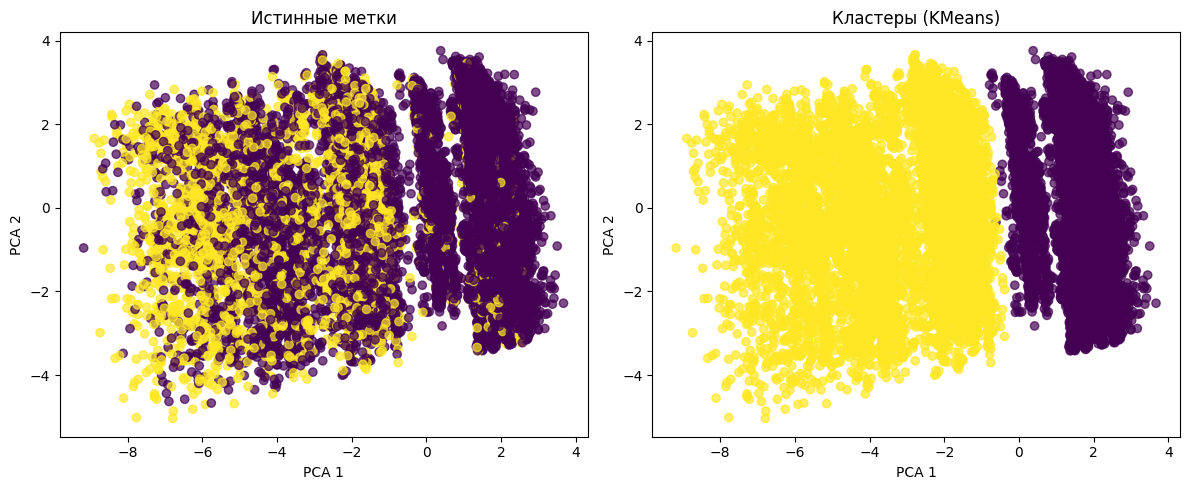

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
best_n_clusters = 2
kmeans = KMeans(n_clusters=best_n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левая диаграмма: истинные метки
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
ax1.set_title("Истинные метки")
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")

# Правая диаграмма: кластеры
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.7)
ax2.set_title("Кластеры (KMeans)")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

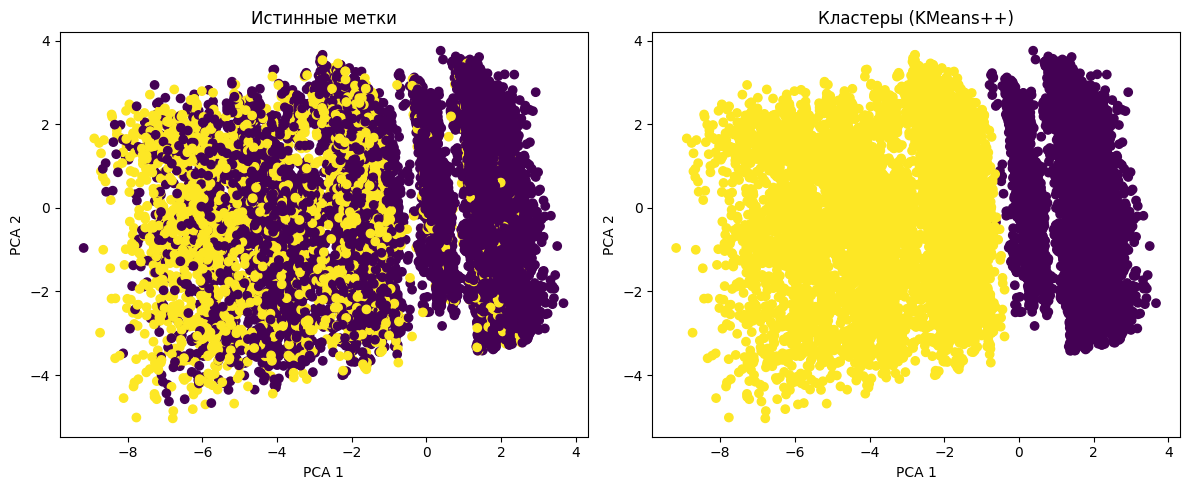

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
best_n_clusters = 2
kmeans_plus_plus = KMeans(n_clusters=n_clusters, init='k-means++', n_init=3)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левая диаграмма: истинные метки
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
ax1.set_title("Истинные метки")
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")

# Правая диаграмма: кластеры
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans_plus_plus, cmap='viridis')
ax2.set_title("Кластеры (KMeans++)")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

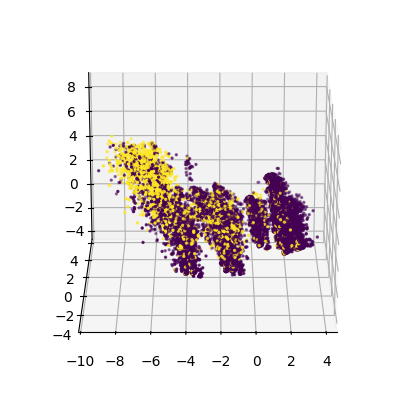

In [13]:
from IPython.display import display, clear_output
import time
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X)
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, s=2)


if False:
  for azim in range(0, 360, 30):
    ax.view_init(10, azim, roll=None, vertical_axis='z')
    display(fig)
    clear_output(wait=True)
    time.sleep(1)
else:
  ax.view_init(20, 270, roll=None, vertical_axis='z')
  plt.show()

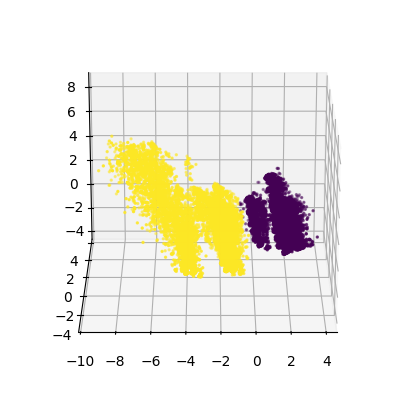

In [14]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=labels_kmeans, s=2)

if False:
  for azim in range(0, 360, 30):
    ax.view_init(10, azim, roll=None, vertical_axis='z')
    display(fig)
    clear_output(wait=True)
    time.sleep(1)
else:
  ax.view_init(20, 270, roll=None, vertical_axis='z')
  plt.show()

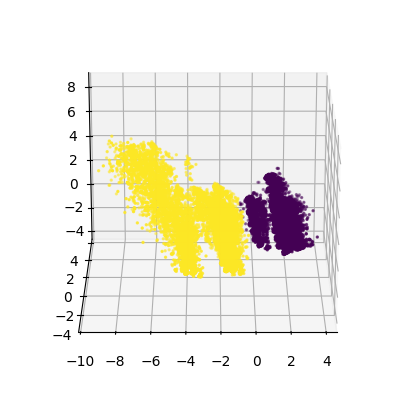

In [15]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=labels_kmeans_plus_plus, s=2)

if False:
  for azim in range(0, 360, 30):
    ax.view_init(10, azim, roll=None, vertical_axis='z')
    display(fig)
    clear_output(wait=True)
    time.sleep(1)
else:
  ax.view_init(20, 270, roll=None, vertical_axis='z')
  plt.show()

In [16]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN().fit(X)
labels_dbscan = dbscan.labels_
score_dbscan = silhouette_score(X, labels_dbscan)
score_dbscan

-0.39251225772767095

In [ ]:
Обычный DBSCAN показывает очень плохую метрику

In [17]:
from sklearn.cluster import HDBSCAN
hdbscan = HDBSCAN().fit(X)
labels_hdbscan = hdbscan.labels_
score_hdbscan = silhouette_score(X, labels_hdbscan)
score_hdbscan

0.11623007284276439

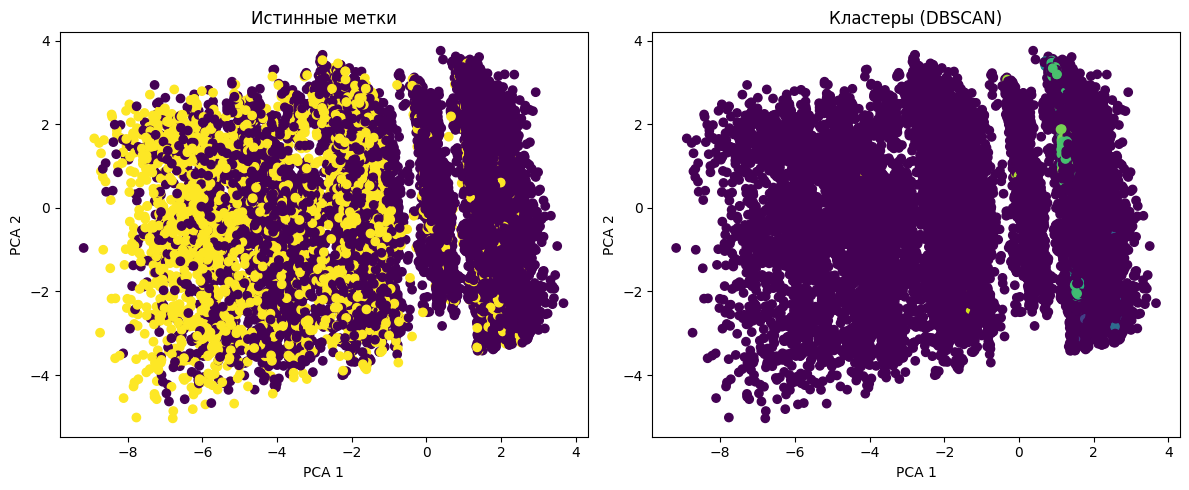

In [18]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левая диаграмма: истинные метки
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
ax1.set_title("Истинные метки")
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")

# Правая диаграмма: кластеры
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, cmap='viridis')
ax2.set_title("Кластеры (DBSCAN)")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

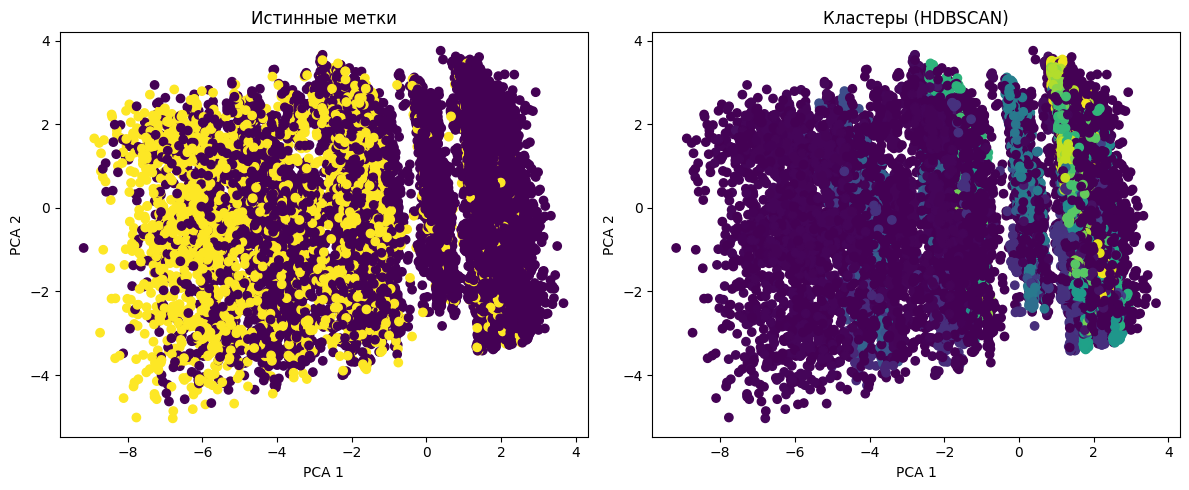

In [19]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левая диаграмма: истинные метки
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
ax1.set_title("Истинные метки")
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")

# Правая диаграмма: кластеры
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hdbscan, cmap='viridis')
ax2.set_title("Кластеры (HDBSCAN)")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

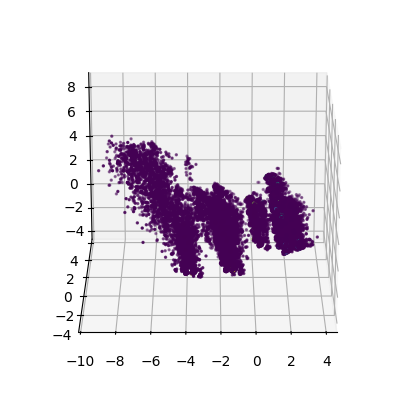

In [20]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=labels_dbscan, s=2)

if False:
  for azim in range(0, 360, 30):
    ax.view_init(10, azim, roll=None, vertical_axis='z')
    display(fig)
    clear_output(wait=True)
    time.sleep(1)
else:
  ax.view_init(20, 270, roll=None, vertical_axis='z')
  plt.show()

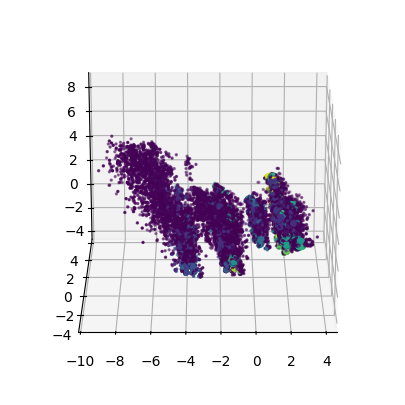

In [22]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=labels_hdbscan, s=2)

if False:
  for azim in range(0, 360, 30):
    ax.view_init(10, azim, roll=None, vertical_axis='z')
    display(fig)
    clear_output(wait=True)
    time.sleep(1)
else:
  ax.view_init(20, 270, roll=None, vertical_axis='z')
  plt.show()

In [23]:
from sklearn.metrics import adjusted_rand_score
ari_labels_kmeans = adjusted_rand_score(y, labels_kmeans)
ari_labels_kmeans_plus_plus = adjusted_rand_score(y, labels_kmeans_plus_plus)
ari_labels_dbscan = adjusted_rand_score(y, labels_dbscan)
ari_labels_hdbscan = adjusted_rand_score(y, labels_hdbscan)

print(ari_labels_kmeans)
print(ari_labels_kmeans_plus_plus)
print(ari_labels_dbscan)
print(ari_labels_hdbscan)

0.11467645679649456
0.11467645679649456
-0.09516446183985616
-0.01783658895816342


In [25]:
from sklearn.cluster import MeanShift, estimate_bandwidth
# 1. Автоматическая оценка bandwidth
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=500)
print(f"Estimated bandwidth: {bandwidth:.3f}")

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, 
               cluster_all=True, min_bin_freq=5, n_jobs=-1)

ms.fit(X)

labels_ms = ms.labels_
cluster_centers = ms.cluster_centers_
n_clusters = len(np.unique(labels_ms))
print(f"Найдено кластеров: {n_clusters}")
ari_labels_ms = adjusted_rand_score(y, labels_ms)
ari_labels_ms

Estimated bandwidth: 8.689
Найдено кластеров: 7


0.3098646808544307

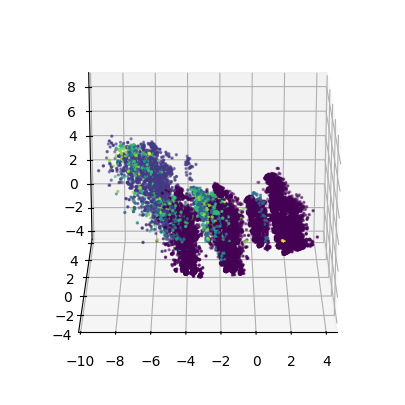

In [26]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=labels_ms, s=2)

if False:
  for azim in range(0, 360, 30):
    ax.view_init(10, azim, roll=None, vertical_axis='z')
    display(fig)
    clear_output(wait=True)
    time.sleep(1)
else:
  ax.view_init(20, 270, roll=None, vertical_axis='z')
  plt.show()

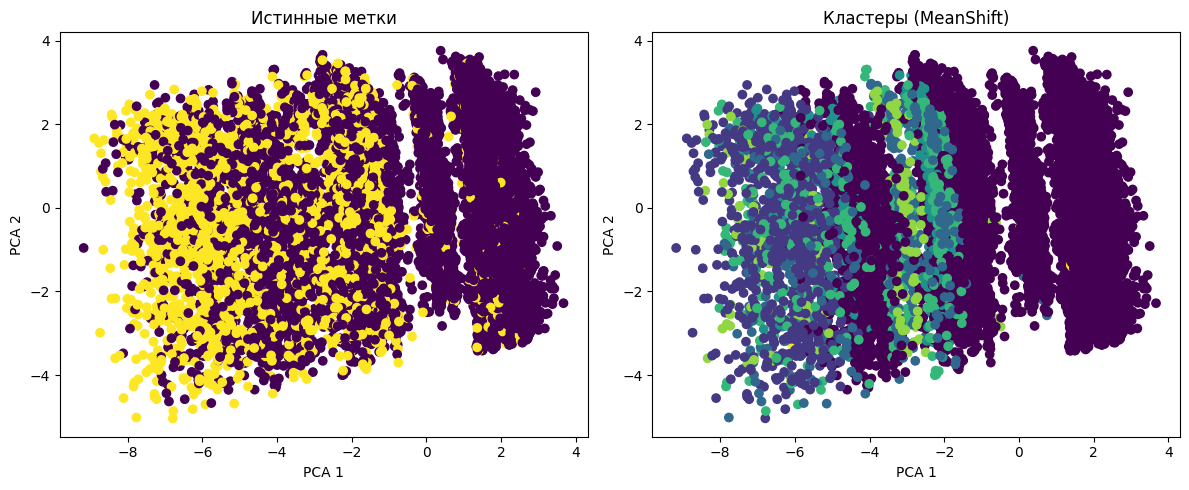

In [27]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Левая диаграмма: истинные метки
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
ax1.set_title("Истинные метки")
ax1.set_xlabel("PCA 1")
ax1.set_ylabel("PCA 2")

# Правая диаграмма: кластеры
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_ms, cmap='viridis')
ax2.set_title("Кластеры (MeanShift)")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")

plt.tight_layout()
plt.show()

In [28]:
# Итог
print(ari_labels_kmeans)
print(ari_labels_kmeans_plus_plus)
print(ari_labels_dbscan)
print(ari_labels_hdbscan)
print(ari_labels_ms)

0.11467645679649456
0.11467645679649456
-0.09516446183985616
-0.01783658895816342
0.3098646808544307
